# Vision template workflow: screenshot → FEN

This notebook runs the full pipeline step by step so you can see:
1. Board detection (corners)
2. Warp to 400×400
3. 64 squares extracted
4. Templates loaded (empty + pieces)
5. Per-square matching (occupancy first, then piece) → FEN

## 1. Setup

In [61]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

from src.agent.vision_template import (
    find_board_corners_contour,
    find_board_corners_edges,
    load_templates,
    image_to_fen_template,
    SQUARE_SIZE,
    BOARD_SIZE,
)
from src.agent.vision_template import _warp_board, _extract_squares, _sort_corners
from src.agent.vision_template import _match_square_to_templates, _squares_to_fen, _variance_in_center

%matplotlib inline

## 2. Configuration

In [62]:
# Path to screenshot (relative to project root)
IMAGE_PATH = project_root / "sample_screenshot.png"

# Board detection: "contour" or "edges"
METHOD = "contour"

# Templates directory (Chess.com-style: wp.png, bk.png, 200.png, etc.)
TEMPLATES_DIR = project_root / "templates"

# Theme-agnostic thresholds
EMPTY_THRESHOLD = 0.9
PIECE_THRESHOLD = 0.1
NORMALIZE = True
# Variance occupancy: if set, squares with center variance below this are empty (flat)
VARIANCE_EMPTY_THRESHOLD = 100.0  # None = use empty-template correlation only
# Edge-based piece matching (shape, theme-agnostic): combine with normalized score
USE_EDGES = True
EDGE_WEIGHT = 0.5   # 0 = normalized only, 1 = edge only
EDGE_METHOD = "gradient"  # "gradient" (Sobel) or "canny"

## 3. Load screenshot

Image shape: (1079, 1920, 3)


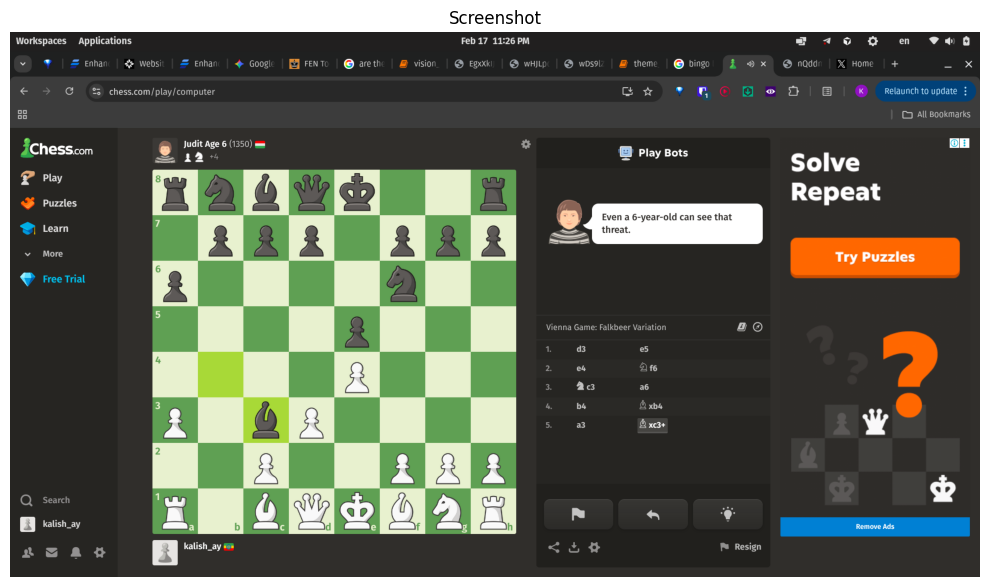

In [63]:
img = np.array(Image.open(IMAGE_PATH).convert("RGB"))
print(f"Image shape: {img.shape}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img)
ax.set_title("Screenshot")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Detect board corners

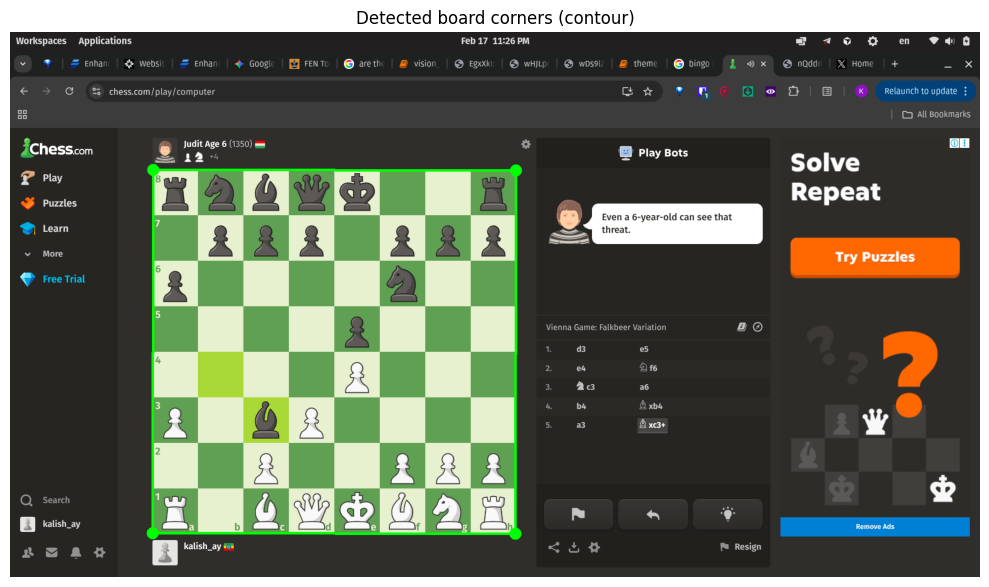

In [64]:
if METHOD == "contour":
    corners = find_board_corners_contour(img)
else:
    corners = find_board_corners_edges(img)

if corners is None:
    raise RuntimeError("Board not detected. Try the other method or another screenshot.")

img_marked = cv2.cvtColor(img.copy(), cv2.COLOR_RGB2BGR)
pts = corners.astype(np.int32)
cv2.polylines(img_marked, [pts], isClosed=True, color=(0, 255, 0), thickness=4)
for x, y in pts:
    cv2.circle(img_marked, (int(x), int(y)), 12, (0, 255, 0), -1)
img_marked_rgb = cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img_marked_rgb)
ax.set_title(f"Detected board corners ({METHOD})")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Warp board to 400×400

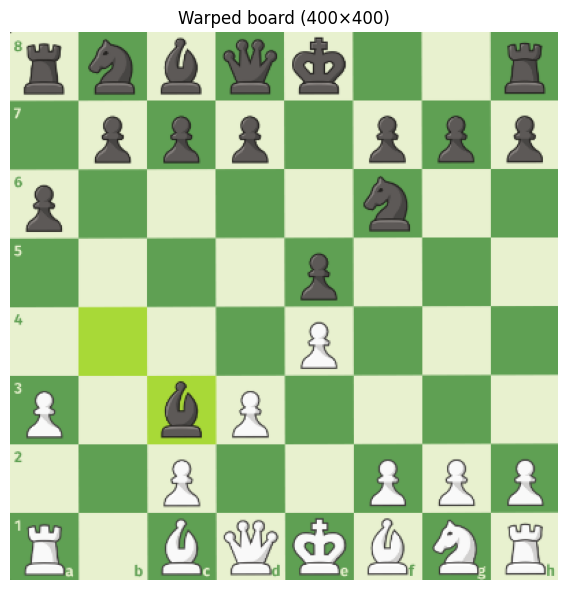

In [65]:
warped = _warp_board(img, corners)
# img is RGB, so warped is RGB
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(warped)
ax.set_title("Warped board (400×400)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Extract 64 squares (8×8 grid)

Extracted 64 squares, each 50×50


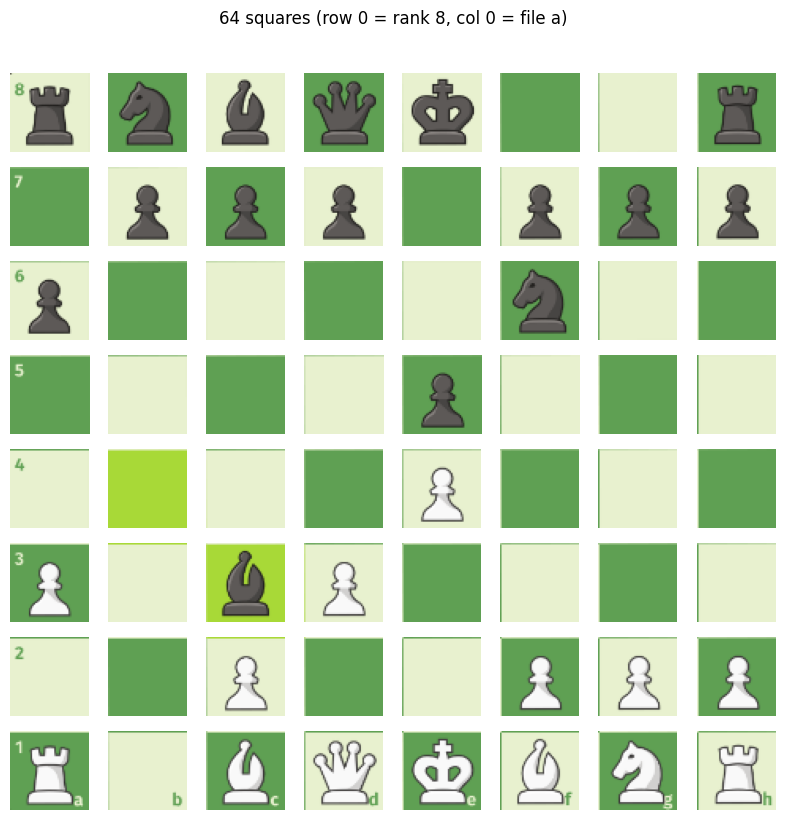

In [66]:
squares = _extract_squares(warped)
print(f"Extracted {len(squares)} squares, each {SQUARE_SIZE}×{SQUARE_SIZE}")

# Show 8×8 grid of squares (small thumbnails)
grid_size = 8
fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        sq = squares[idx]
        axes[row, col].imshow(sq)
        axes[row, col].axis("off")
plt.suptitle("64 squares (row 0 = rank 8, col 0 = file a)", y=1.02)
plt.tight_layout()
plt.show()

## 6b. Variance per square (occupancy cue)

Flat (empty) squares have **low variance**; squares with a piece have **higher variance**. Below: each cell shows the square image and its center variance. Use this to tune `VARIANCE_EMPTY_THRESHOLD` (squares with var &lt; threshold are labeled empty).

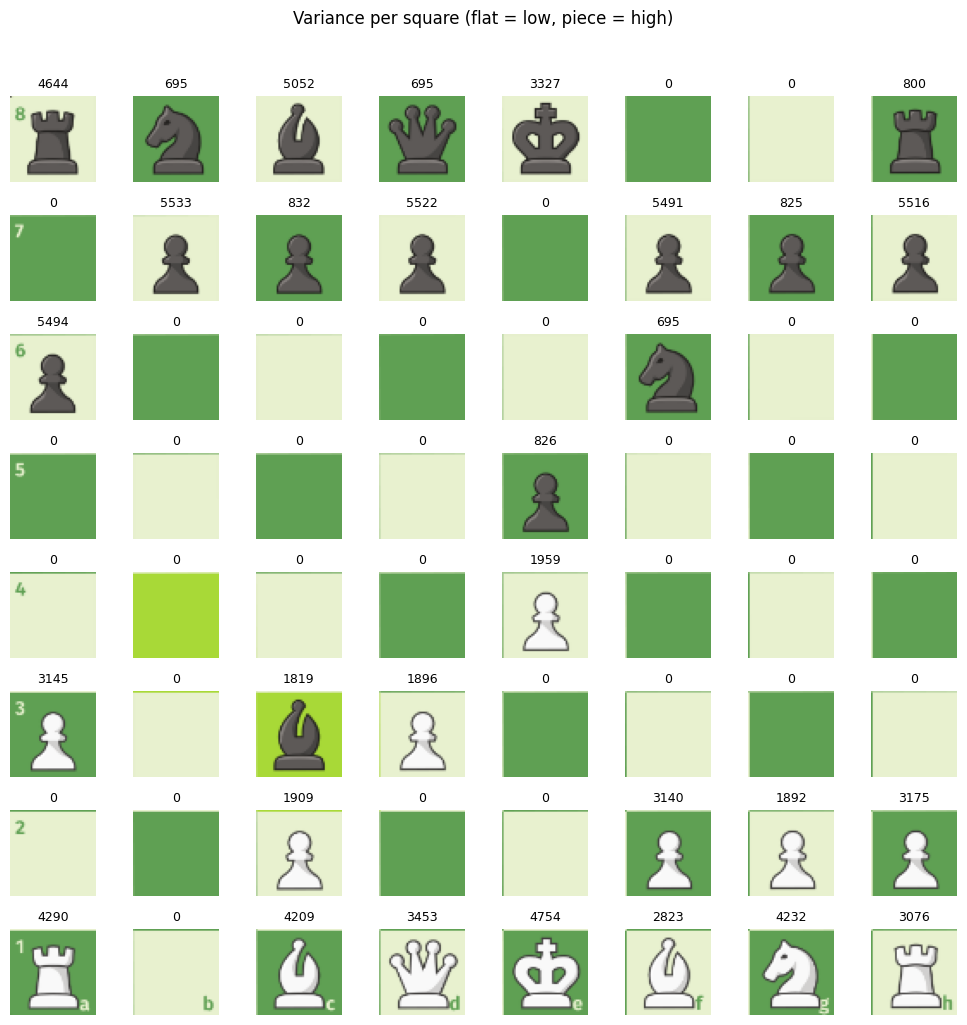

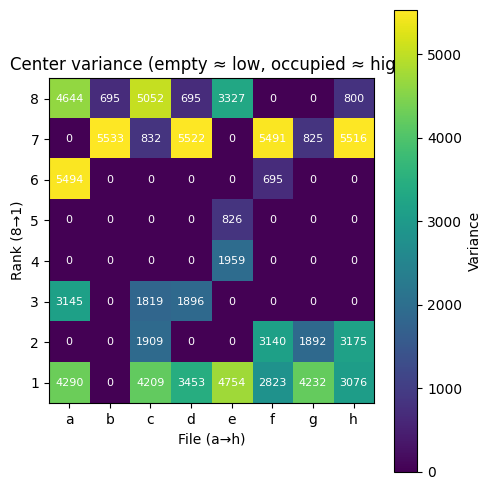

In [67]:
# Variance in center (60% of each square) — used for occupancy when VARIANCE_EMPTY_THRESHOLD is set
variances = [_variance_in_center(sq) for sq in squares]
var_grid = np.array(variances).reshape(8, 8)

# 1) 8×8 grid: each cell = square image + variance as title
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        axes[row, col].imshow(squares[idx])
        axes[row, col].set_title(f"{variances[idx]:.0f}", fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("Variance per square (flat = low, piece = high)", y=1.02)
plt.tight_layout()
plt.show()

# 2) Heatmap of variance only (easier to spot empty vs occupied)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.imshow(var_grid, cmap="viridis")
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{var_grid[i, j]:.0f}", ha="center", va="center", color="white", fontsize=8)
ax.set_xlabel("File (a→h)")
ax.set_ylabel("Rank (8→1)")
ax.set_xticks(range(8))
ax.set_xticklabels(["a", "b", "c", "d", "e", "f", "g", "h"])
ax.set_yticks(range(8))
ax.set_yticklabels(["8", "7", "6", "5", "4", "3", "2", "1"])
plt.colorbar(im, ax=ax, label="Variance")
plt.title("Center variance (empty ≈ low, occupied ≈ high)")
plt.tight_layout()
plt.show()

## 7. Load templates

In [68]:
templates = load_templates(TEMPLATES_DIR, target_size=SQUARE_SIZE)
empty_templates = [(t, m, c) for t, m, c in templates if c == "."]
piece_templates = [(t, m, c) for t, m, c in templates if c != "."]

print(f"Loaded {len(templates)} templates: {len(empty_templates)} empty, {len(piece_templates)} pieces")
print(f"Empty FEN: '.'  |  Piece FEN chars: {sorted(set(c for _, _, c in piece_templates))}")

Loaded 14 templates: 2 empty, 12 pieces
Empty FEN: '.'  |  Piece FEN chars: ['B', 'K', 'N', 'P', 'Q', 'R', 'b', 'k', 'n', 'p', 'q', 'r']


## 8. Match each square (occupancy first, then piece)

In [69]:
square_fen_chars = [
    _match_square_to_templates(
        sq,
        empty_templates,
        piece_templates,
        EMPTY_THRESHOLD,
        PIECE_THRESHOLD,
        normalize=NORMALIZE,
        variance_empty_threshold=VARIANCE_EMPTY_THRESHOLD,
        use_edges=USE_EDGES,
        edge_weight=EDGE_WEIGHT,
        edge_method=EDGE_METHOD,
    )
    for sq in squares
]

fen = _squares_to_fen(square_fen_chars)
print("FEN (piece placement):", fen)

FEN (piece placement): rnbqk2r/1ppp1ppp/p4n2/4p3/4P3/P1bP4/2P2PPP/R1BQKBNR


## 9. Visual result: 8×8 board with labels

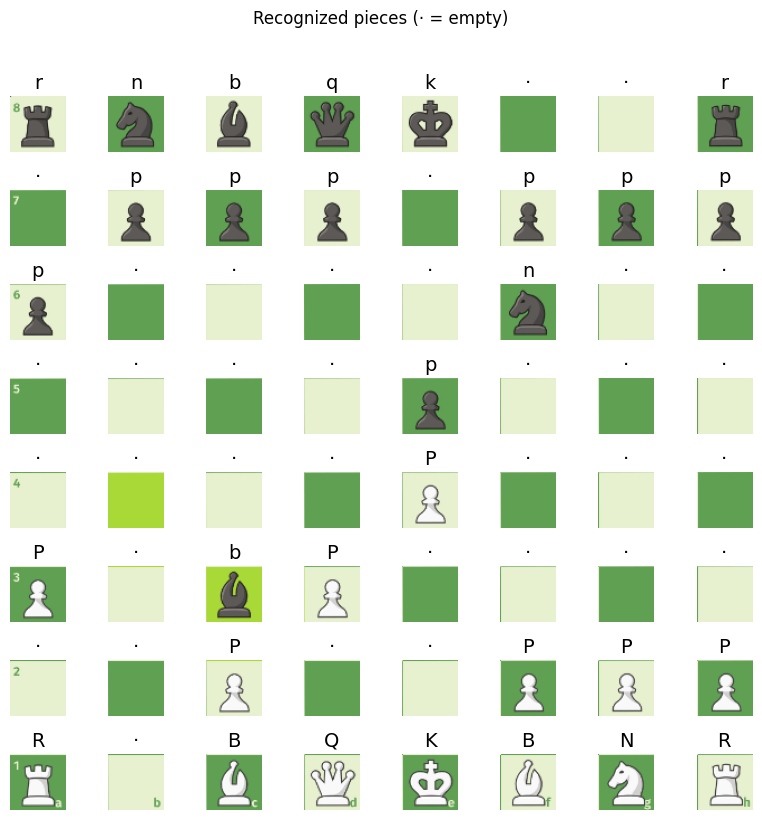

Final FEN: rnbqk2r/1ppp1ppp/p4n2/4p3/4P3/P1bP4/2P2PPP/R1BQKBNR


In [70]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        sq = squares[idx]
        axes[row, col].imshow(sq)
        axes[row, col].set_title(square_fen_chars[idx] if square_fen_chars[idx] != "." else "·", fontsize=14)
        axes[row, col].axis("off")
plt.suptitle("Recognized pieces (· = empty)", y=1.02)
plt.tight_layout()
plt.show()

print("Final FEN:", fen)

## 10. One-shot API (same result)

In [ ]:
# You can also run the full pipeline in one call:
fen_one_shot = image_to_fen_template(
    img,
    TEMPLATES_DIR,
    method=METHOD,
    empty_threshold=EMPTY_THRESHOLD,
    piece_threshold=PIECE_THRESHOLD,
    normalize=NORMALIZE,
    variance_empty_threshold=VARIANCE_EMPTY_THRESHOLD,
    use_edges=USE_EDGES,
    edge_weight=EDGE_WEIGHT,
    edge_method=EDGE_METHOD,
)
print("image_to_fen_template() ->", fen_one_shot)
print("Match step-by-step FEN:", fen)